# Stage 0 — COSMOS Cutout Extraction Prototype (GalSim)

**Goal:** Extract 50 morphologically diverse real galaxy postage stamps from the COSMOS HST/ACS F814W  
catalog via GalSim, apply quality cuts, and save as normalised `.npy` arrays for lenstronomy injection.

**Environment:** Ubuntu/WSL — GalSim is Linux-only and must be run here.

---
### Pipeline position
```
THIS NOTEBOOK   ->  02_lensing_simulation_prototype.ipynb
COSMOS cutouts  ->  lenstronomy source injection  ->  (LR 64x64, HR 128x128) pairs
```

### What this notebook does
1. Downloads the COSMOS 23.5-sample catalog via `galsim_download_cosmos`
2. Loads the catalog and inspects the available morphological columns
3. Applies quality cuts (Sersic fit quality, size, axis ratio, magnitude)
4. Stratified-samples 50 galaxies across morphological types
5. Draws each galaxy to a 2D image using GalSim RealGalaxy (actual HST pixel data)
6. Normalises and saves as `.npy` arrays + metadata JSON
7. Produces a 5x10 visualisation grid and diversity diagnostics

### Why the 23.5 sample (not 25.2)
| Sample | Galaxies | Download size | Use case |
|--------|----------|---------------|----------|
| 23.5   | ~56,000  | ~700 MB       | Prototype + fast iteration (this notebook) |
| 25.2   | ~87,000  | ~6 GB unpacked | Full production Stage 0 dataset |

In [1]:
import sys, platform, os
import galsim

print("GalSim version:", galsim.__version__)
print("Python executable:", sys.executable)
print("Platform:", platform.platform())
print("Current working dir:", os.getcwd())

GalSim version: 2.8.4
Python executable: /home/udayprajwal/miniconda3/envs/lenssim/bin/python
Platform: Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
Current working dir: /mnt/c/Users/upraj/Prajwal/GSOC/DeepLense/DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday


## Cell 1 — Install dependencies

In [2]:
import subprocess, sys

packages = ['galsim', 'numpy', 'matplotlib', 'scipy', 'tqdm', 'pandas', 'astropy']

for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = 'OK' if result.returncode == 0 else 'FAILED'
    print(f'[{status}] {pkg}')

import galsim
print(f'\nGalSim version: {galsim.__version__}')

[OK] galsim
[OK] numpy
[OK] matplotlib
[OK] scipy
[OK] tqdm
[OK] pandas
[OK] astropy

GalSim version: 2.8.4


## Cell 2 — Download the COSMOS catalog

Runs `galsim_download_cosmos` to download the F814W < 23.5 sample (~700 MB).  
**This only needs to run once.** GalSim remembers the install location afterwards.

The download installs into GalSim's share directory automatically:
`~/.local/lib/pythonX.Y/site-packages/galsim/share/COSMOS_23.5_training_sample/`

If the catalog is already downloaded, this cell will print a message and exit quickly.

In [3]:
import subprocess

print('Starting COSMOS 23.5 catalog download (~700 MB) ...')
print('Expected time: 5-20 minutes depending on connection speed.\n')

# -s 23.5  : download the smaller 23.5-magnitude sample (not the 6 GB 25.2 sample)
# -q       : quiet mode, fewer interactive prompts
result = subprocess.run(
    ['galsim_download_cosmos', '-s', '23.5', '-q'],
    capture_output=False,
    text=True,
)

if result.returncode == 0:
    print('\n[OK] COSMOS catalog download complete (or was already present).')
else:
    print(f'\n[FAILED] Return code: {result.returncode}')
    print('Try running this manually in your WSL terminal:')
    print('  galsim_download_cosmos -s 23.5')

Starting COSMOS 23.5 catalog download (~700 MB) ...
Expected time: 5-20 minutes depending on connection speed.

Type galsim_download_cosmos -h to see command line options.

  https://zenodo.org/record/3242143/files/COSMOS_23.5_training_sample.tar.gz
Target location is:
  /home/udayprajwal/miniconda3/envs/lenssim/lib/python3.10/site-packages/galsim/share/COSMOS_23.5_training_sample.tar.gz

Size of COSMOS_23.5_training_sample.tar.gz: 4215 MBytes

Checksum key oc-checksum matches.  File is up to date.
Target file has already been downloaded and unpacked.  Not re-downloading.

[OK] COSMOS catalog download complete (or was already present).


## Cell 3 — Imports and configuration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import galsim
import json
import warnings
from pathlib import Path
from tqdm.auto import tqdm
from scipy.stats import sigmaclip

warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────────────────────────

N_PROTOTYPE = 50             # Number of galaxy cutouts for this prototype

# Output pixel scale.
# 0.05"/px matches the native COSMOS ACS drizzled mosaic scale.
# lenstronomy will use this when projecting the source through the lens.
PIXEL_SCALE_ARCSEC = 0.03

# Output image size in pixels.
# 200 px x 0.05"/px = 10" side length.
# Typical COSMOS galaxy half-light radius: 0.3" to 2.0".
# 10" gives ample sky background around every galaxy in our size range.
N_PIX = 128

# Reconvolution PSF FWHM (arcsec).
# EXPLANATION: GalSim's RealGalaxy has already DECONVOLVED the original HST PSF.
# Drawing it directly causes ringing artefacts at high spatial frequencies.
# We must reconvolve with a tiny Gaussian before drawImage to suppress those.
# Keep this much smaller than the HST PSF FWHM (~0.09") to preserve structure.
RECONV_PSF_FWHM = 0.15   # arcsec

RNG_SEED = 13

OUT_DIR = Path('cosmos_cutouts')
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / 'npy').mkdir(exist_ok=True)

print(f'GalSim version   : {galsim.__version__}')
print(f'Output directory : {OUT_DIR.resolve()}')
print(f'Prototype size   : {N_PROTOTYPE} galaxies')
print(f'Pixel scale      : {PIXEL_SCALE_ARCSEC}"/px')
print(f'Image size       : {N_PIX} x {N_PIX} px  = {N_PIX * PIXEL_SCALE_ARCSEC}" x {N_PIX * PIXEL_SCALE_ARCSEC}"')

/home/udayprajwal/miniconda3/envs/lenssim/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GalSim version   : 2.8.4
Output directory : /mnt/c/Users/upraj/Prajwal/GSOC/DeepLense/DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday/cosmos_cutouts
Prototype size   : 50 galaxies
Pixel scale      : 0.03"/px
Image size       : 128 x 128 px  = 3.84" x 3.84"


## Cell 4 — Load the COSMOS catalog

### GalSim exclusion levels explained

| Level | What it excludes |
|-------|------------------|
| `none` | Nothing — raw catalog |
| `bad_stamp` | Galaxies with bad postage stamp flags |
| `bad_fits` | Above + failed Sersic fits |
| `marginal` | Above + marginal Sersic fits (n>5 AND large hlr) — GalSim recommended |
| `no_cas_dilution` | Most aggressive — only clean isolated objects |

We use `exclusion_level='marginal'` which is GalSim's recommended default for science use.

In [5]:
print('Loading COSMOS 23.5 catalog ...')

cosmos_cat = galsim.COSMOSCatalog(
    sample='23.5',
    exclusion_level='marginal',   # GalSim recommended quality cut
    use_real=True,                # Want real HST pixel data, not parametric only
)

print(f'[OK] Catalog loaded successfully.')
print(f'   Total objects after exclusion cuts : {cosmos_cat.nobjects:,}')
print(f'   use_real                           : {cosmos_cat.use_real}')

param_cat = cosmos_cat.param_cat
print(f'\nparam_cat shape  : {param_cat.shape}')
print(f'param_cat columns: {list(param_cat.dtype.names)}')

Loading COSMOS 23.5 catalog ...
[OK] Catalog loaded successfully.
   Total objects after exclusion cuts : 50,932
   use_real                           : True

param_cat shape  : (56062,)
param_cat columns: ['IDENT', 'mag_auto', 'flux_radius', 'zphot', 'sersicfit', 'bulgefit', 'fit_status', 'fit_mad_s', 'fit_mad_b', 'fit_dvc_btt', 'use_bulgefit', 'viable_sersic', 'hlr', 'flux']


## Cell 5 — Inspect catalog columns

Key GalSim COSMOS catalog parameter columns:

| Column | Shape | Units | Description |
|--------|-------|-------|-------------|
| `mag_auto` | scalar | F814W mag | Total SExtractor AUTO magnitude |
| `flux` | (3,) | counts | [0]=single Sersic, [1]=bulge, [2]=disk |
| `hlr` | (3,) | arcsec | Half-light radii: [0]=single, [1]=bulge, [2]=disk |
| `sersicfit` | (8,) | mixed | [0]=I_e, [1]=hlr_px, [2]=n, [3]=q(b/a), [4]=box, [5]=x0, [6]=y0, [7]=phi |
| `fit_status` | (5,) | int | Fit convergence: [4]=single Sersic, [0]=bulge |
| `use_bulgefit` | bool | | Whether GalSim uses bulge+disk or single Sersic |
| `viable_sersic` | bool | | Whether single Sersic fit is usable |
| `zphot` | scalar | | Photometric redshift |

For morphological cuts we use:
- `mag_auto` for brightness cut
- `hlr[:,0]` for angular size cut (single Sersic half-light radius in arcsec)
- `sersicfit[:,2]` for Sersic n (profile shape)
- `sersicfit[:,3]` for q = b/a (axis ratio — we compute elongation = 1/q)
- `fit_status[:,4]` for fit quality flag

In [6]:
# # Extract key columns into a pandas DataFrame for easy filtering and sampling

# has_zphot = 'zphot' in param_cat.dtype.names

# df = pd.DataFrame({
#     'index'       : np.arange(len(param_cat)),
#     'mag_auto'    : param_cat['mag_auto'],
#     'hlr_arcsec'  : param_cat['hlr'][:, 0],         # single-Sersic half-light radius in arcsec
#     'sersic_n'    : param_cat['sersicfit'][:, 2],    # Sersic index n
#     'q_axis'      : param_cat['sersicfit'][:, 3],    # b/a axis ratio (0 < q <= 1)
#     'fit_status'  : param_cat['fit_status'][:, 4],   # single Sersic fit status
#     'use_bulgefit': param_cat['use_bulgefit'].astype(bool),
#     'viable'      : param_cat['viable_sersic'].astype(bool),
#     'zphot'       : param_cat['zphot'] if has_zphot else np.nan,
# })

# # Elongation = a/b = 1/q  (q = b/a, so elongation > 1 means non-circular)
# df['elongation'] = 1.0 / np.clip(df['q_axis'], 1e-3, None)

# print(f'Total galaxies in catalog: {len(df):,}')
# print()
# display_cols = ['mag_auto', 'hlr_arcsec', 'sersic_n', 'q_axis', 'elongation']
# if has_zphot:
#     display_cols.append('zphot')
# print('Key column statistics:')
# print(df[display_cols].describe().round(3).to_string())


# Extract key columns into a pandas DataFrame for easy filtering and sampling

has_zphot = 'zphot' in param_cat.dtype.names

def native_array(x, dtype=None):
    arr = np.asarray(x)

    # Convert non-native-endian arrays to native-endian
    if not arr.dtype.isnative and arr.dtype.kind != 'b':
        arr = arr.byteswap().view(arr.dtype.newbyteorder('='))

    # Optional dtype cast
    if dtype is not None:
        arr = np.asarray(arr, dtype=dtype)

    # Make sure pandas gets a normal contiguous native-endian array
    return np.ascontiguousarray(arr)

mag_auto = native_array(param_cat['mag_auto'], np.float64)
hlr_arcsec = native_array(param_cat['hlr'][:, 0], np.float64)          # single-Sersic HLR in arcsec
sersic_n = native_array(param_cat['sersicfit'][:, 2], np.float64)      # Sersic index n
q_axis = native_array(param_cat['sersicfit'][:, 3], np.float64)        # b/a axis ratio
fit_status = native_array(param_cat['fit_status'][:, 4], np.int32)     # single-Sersic fit status
use_bulgefit = native_array(param_cat['use_bulgefit'], np.bool_)
viable = native_array(param_cat['viable_sersic'], np.bool_)

if has_zphot:
    zphot = native_array(param_cat['zphot'], np.float64)
else:
    zphot = np.full(len(param_cat), np.nan, dtype=np.float64)

df = pd.DataFrame({
    'index': np.arange(len(param_cat), dtype=np.int32),
    'mag_auto': mag_auto,
    'hlr_arcsec': hlr_arcsec,
    'sersic_n': sersic_n,
    'q_axis': q_axis,
    'fit_status': fit_status,
    'use_bulgefit': use_bulgefit,
    'viable': viable,
    'zphot': zphot,
})

# Elongation = a/b = 1/q
df['elongation'] = 1.0 / np.clip(df['q_axis'].to_numpy(dtype=np.float64), 1e-3, None)

print(f'Total galaxies in catalog: {len(df):,}')
print()
display_cols = ['mag_auto', 'hlr_arcsec', 'sersic_n', 'q_axis', 'elongation']
if has_zphot:
    display_cols.append('zphot')
print('Key column statistics:')
print(df[display_cols].describe().round(3).to_string())

print("\nDtypes:")
print(df.dtypes)

Total galaxies in catalog: 56,062

Key column statistics:
        mag_auto  hlr_arcsec   sersic_n     q_axis  elongation      zphot
count  56062.000   56062.000  56062.000  56062.000   56062.000  56062.000
mean      22.295       0.556      1.878      0.568       2.211      0.690
std        1.067      16.692      1.569      0.211       8.514      0.370
min       16.118       0.000      0.000      0.000       1.002      0.001
25%       21.761       0.238      0.779      0.401       1.356      0.394
50%       22.591       0.350      1.244      0.573       1.745      0.673
75%       23.116       0.506      2.450      0.737       2.496      0.903
max       23.500    3633.899      6.000      0.998    1000.000      4.913

Dtypes:
index             int32
mag_auto        float64
hlr_arcsec      float64
sersic_n        float64
q_axis          float64
fit_status        int32
use_bulgefit       bool
viable             bool
zphot           float64
elongation      float64
dtype: object


## Cell 6 — Morphological quality cuts

| # | Cut | Threshold | Reason |
|---|-----|-----------|--------|
| 1 | Sersic fit quality | `fit_status in {1,2,3,4}` | 0 = failed or did not converge |
| 2 | Viable Sersic flag | `viable_sersic == True` | GalSim's own QA flag |
| 3 | Magnitude | `18 <= mag_auto <= 23.5` | Bright limit: saturation; faint limit: sample boundary |
| 4 | Angular size (lower) | `hlr > 0.05"` | Below this: unresolved, PSF-dominated |
| 5 | Angular size (upper) | `hlr < 1.5"` | Above this: galaxy fills or overflows the 10" cutout |
| 6 | Axis ratio | `elongation < 3.0` | a/b > 3 = strongly edge-on disk |

Note: `exclusion_level='marginal'` was already applied at load time to remove bad stamps.  
These cuts refine further specifically for lensing source injection use.

In [7]:
# original_count = len(df)

# # Cut 1: Sersic fit status (0 = failed)
# df = df[df['fit_status'].isin([1, 2, 3, 4])]
# print(f'After fit_status cut (1-4)         : {len(df):>7,}  ({100*len(df)/original_count:.1f}%)')

# # Cut 2: Viable Sersic flag
# df = df[df['viable'] == True]
# print(f'After viable_sersic cut            : {len(df):>7,}  ({100*len(df)/original_count:.1f}%)')

# # Cut 3: Magnitude range
# df = df[(df['mag_auto'] >= 18.0) & (df['mag_auto'] <= 23.5)]
# print(f'After magnitude cut (18-23.5)      : {len(df):>7,}  ({100*len(df)/original_count:.1f}%)')

# # Cut 4 & 5: Angular size
# df = df[(df['hlr_arcsec'] > 0.05) & (df['hlr_arcsec'] < 1.5)]
# print(f'After size cut (0.05"-1.5")        : {len(df):>7,}  ({100*len(df)/original_count:.1f}%)')

# # Cut 6: Axis ratio
# df = df[df['elongation'] < 3.0]
# print(f'After elongation cut (a/b < 3.0)   : {len(df):>7,}  ({100*len(df)/original_count:.1f}%)')

# print(f'\n-> Final pool: {len(df):,} galaxies available for sampling')
# print(f'-> Will sample: {N_PROTOTYPE} galaxies')

# assert len(df) >= N_PROTOTYPE, f'Pool too small ({len(df)} galaxies) — loosen the cuts'
# df = df.reset_index(drop=True)


df_cut = df.copy()
original_count = len(df_cut)

# Cut 1: Sersic fit status (0 = failed)
df_cut = df_cut[df_cut['fit_status'].isin([1, 2, 3, 4])]
print(f'After fit_status cut (1-4)      : {len(df_cut):>7,} ({100*len(df_cut)/original_count:.1f}%)')

# Cut 2: Viable Sersic flag
df_cut = df_cut[df_cut['viable']]
print(f'After viable_sersic cut         : {len(df_cut):>7,} ({100*len(df_cut)/original_count:.1f}%)')

# Cut 3: Magnitude range
df_cut = df_cut[(df_cut['mag_auto'] >= 18.0) & (df_cut['mag_auto'] <= 21.5)]
print(f'After magnitude cut (18-23.5)   : {len(df_cut):>7,} ({100*len(df_cut)/original_count:.1f}%)')

# Cut 4 & 5: Angular size
df_cut = df_cut[(df_cut['hlr_arcsec'] >= 0.3) & (df_cut['hlr_arcsec'] < 1.2)]
print(f'After size cut (0.05\"-1.5\")     : {len(df_cut):>7,} ({100*len(df_cut)/original_count:.1f}%)')

# Cut 6: Axis ratio
df_cut = df_cut[df_cut['elongation'] < 2.2]
print(f'After elongation cut (a/b < 3)  : {len(df_cut):>7,} ({100*len(df_cut)/original_count:.1f}%)')

print(f'\n-> Final pool: {len(df_cut):,} galaxies available for sampling')
print(f'-> Will sample: {N_PROTOTYPE} galaxies')

assert len(df_cut) >= N_PROTOTYPE, f'Pool too small ({len(df_cut)} galaxies) — loosen the cuts'

df = df_cut.reset_index(drop=True)

After fit_status cut (1-4)      :  56,058 (100.0%)
After viable_sersic cut         :  56,056 (100.0%)
After magnitude cut (18-23.5)   :  10,854 (19.4%)
After size cut (0.05"-1.5")     :   8,751 (15.6%)
After elongation cut (a/b < 3)  :   6,418 (11.4%)

-> Final pool: 6,418 galaxies available for sampling
-> Will sample: 50 galaxies


## Cell 7 — Visualise cut catalog distributions

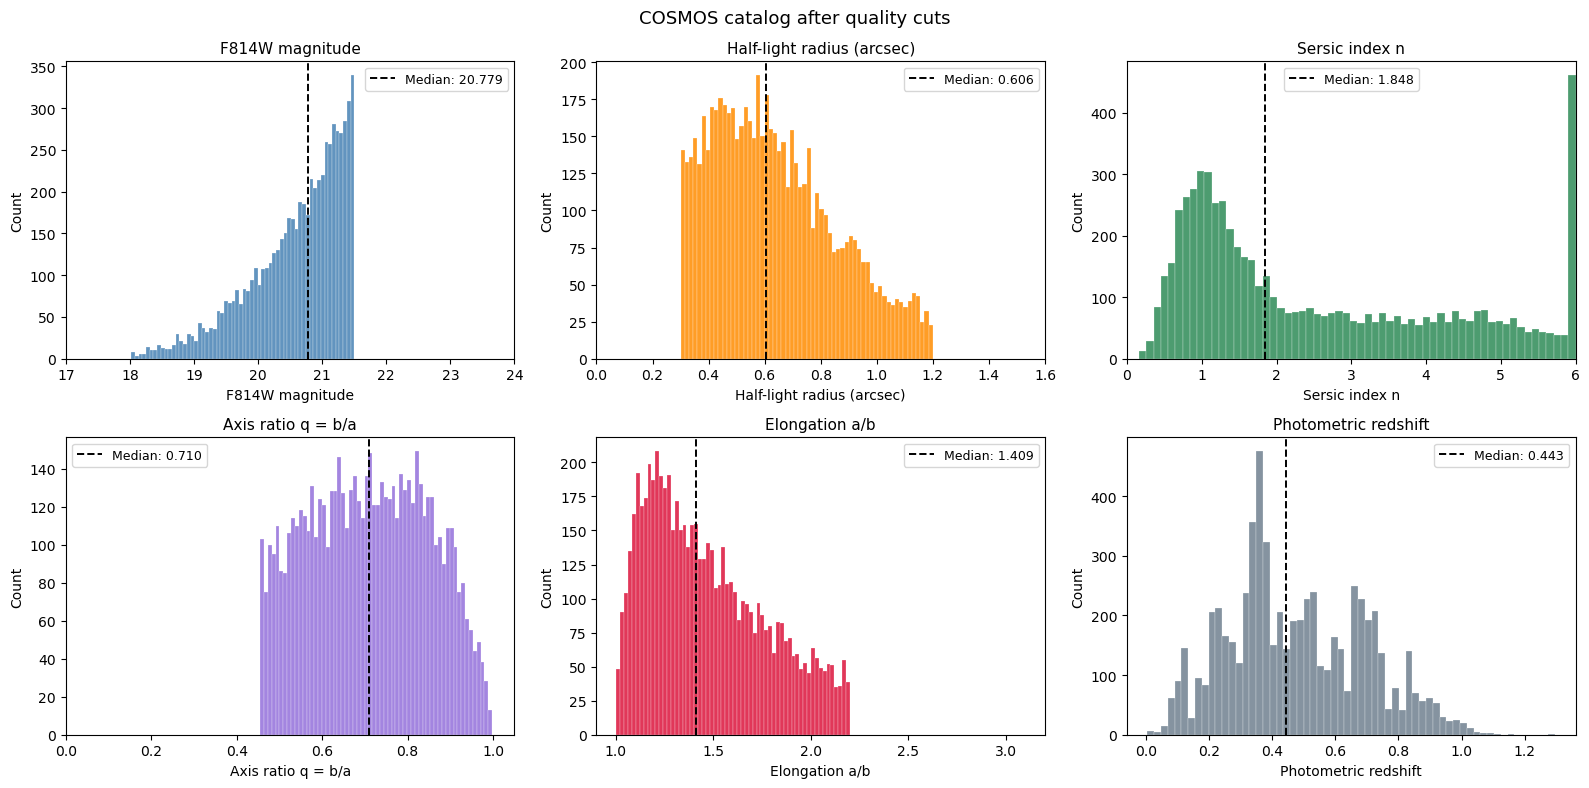

Saved: catalog_distributions.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle('COSMOS catalog after quality cuts', fontsize=13)

plot_specs = [
    ('mag_auto',   'F814W magnitude',           (17, 24),    'steelblue'),
    ('hlr_arcsec', 'Half-light radius (arcsec)', (0, 1.6),   'darkorange'),
    ('sersic_n',   'Sersic index n',             (0, 6),     'seagreen'),
    ('q_axis',     'Axis ratio q = b/a',         (0, 1.05),  'mediumpurple'),
    ('elongation', 'Elongation a/b',             (0.9, 3.2), 'crimson'),
    ('zphot',      'Photometric redshift',        None,       'slategray'),
]

for ax, (col, label, xlim, color) in zip(axes, plot_specs):
    if col not in df.columns or df[col].isnull().all():
        ax.text(0.5, 0.5, f'{col}\nnot available', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(label)
        continue
    data = df[col].dropna()
    ax.hist(data, bins=60, color=color, edgecolor='white', linewidth=0.2, alpha=0.85)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(label, fontsize=11)
    if xlim:
        ax.set_xlim(xlim)
    med = data.median()
    ax.axvline(med, color='black', linestyle='--', linewidth=1.4, label=f'Median: {med:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'catalog_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: catalog_distributions.png')

## Cell 8 — Stratified morphological sampling

We split by Sersic index into three bins that loosely correspond to galaxy types:

| Sersic n | Galaxy type | N sampled |
|----------|-------------|----------|
| n < 1.5  | Irregular / disk-dominated / late-type | 17 |
| 1.5 <= n < 3.5 | Spiral / intermediate | 17 |
| n >= 3.5 | Early-type / elliptical / bulge-dominated | 16 |

This ensures diverse arc morphologies in the lensing simulation.

In [9]:
bins = [
    ('late-type  (n < 1.5)',    df['sersic_n'] < 1.5,                            17),
    ('spiral     (1.5-3.5)',   (df['sersic_n'] >= 1.5) & (df['sersic_n'] < 3.5), 17),
    ('early-type (n >= 3.5)',   df['sersic_n'] >= 3.5,                            16),
]

sampled_parts = []
print(f'{"Bin":<28} {"Available":>10} {"Sampled":>8}')
print('-' * 50)

for label, mask, n_target in bins:
    pool   = df[mask]
    n_draw = min(n_target, len(pool))
    drawn  = pool.sample(n=n_draw, random_state=RNG_SEED)
    sampled_parts.append(drawn)
    print(f'{label:<28} {len(pool):>10,} {n_draw:>8}')

sampled = pd.concat(sampled_parts).reset_index(drop=True)
print('-' * 50)
print(f'{"TOTAL":<28} {"":>10} {len(sampled):>8}')
print(f'\nFirst 5 catalog indices: {list(sampled["index"][:5])}')

Bin                           Available  Sampled
--------------------------------------------------
late-type  (n < 1.5)              2,666       17
spiral     (1.5-3.5)              1,829       17
early-type (n >= 3.5)             1,923       16
--------------------------------------------------
TOTAL                                         50

First 5 catalog indices: [15212, 23324, 48129, 4530, 30770]


## Cell 9 — Galaxy drawing function

### How GalSim draws a RealGalaxy — step by step

```
HST postage stamp stored in COSMOS catalog FITS file
    |
    v  GalSim internally deconvolves the original HST PSF
    |
RealGalaxy object   <-- makeGalaxy(idx, gal_type='real')
    |                   This gives the intrinsic galaxy light profile
    |                   with HST PSF removed
    v
Convolve(RealGalaxy, tiny_Gaussian)   <-- MANDATORY step
    |                                     Without this: ringing artefacts
    |                                     from aliased high-freq content
    v
drawImage(scale=0.05, nx=200, ny=200)  -->  numpy float32 array
```

Why gal_type='real' and not 'parametric'?
- 'parametric' gives a smooth Sersic/bulge+disk model fit — no clumps, no spiral arms
- 'real' gives the actual HST pixels — realistic substructure, asymmetries, clumps
- For lensing SR training, realistic source morphology is critical so the model
  sees arc structures that look like real observations, not idealised profiles

In [10]:
# Pre-build the reconvolution PSF (same for all galaxies)
# sigma = FWHM / 2.355  (Gaussian FWHM to sigma conversion)
reconv_sigma = RECONV_PSF_FWHM / 2.355
RECONV_PSF   = galsim.Gaussian(fwhm=0.15) #galsim.Gaussian(sigma=reconv_sigma)

# GalSim RNG (needed internally by makeGalaxy for noise_pad)
GALSIM_RNG   = galsim.BaseDeviate(RNG_SEED)


def draw_galaxy_image(
    cat_index  : int,
    cosmos_cat : galsim.COSMOSCatalog,
    pixel_scale: float = PIXEL_SCALE_ARCSEC,
    n_pix      : int   = N_PIX,
    #reconv_psf : galsim.GSObject    = RECONV_PSF,
    #rng        : galsim.BaseDeviate = GALSIM_RNG,
) -> np.ndarray:
    """
    Draw one RealGalaxy from the COSMOS catalog as a 2D numpy array.

    Parameters
    ----------
    cat_index   : integer index into the GalSim catalog (after exclusion cuts)
    cosmos_cat  : loaded galsim.COSMOSCatalog object
    pixel_scale : output pixel scale in arcsec/px
    n_pix       : output image side length in pixels (square)
    reconv_psf  : tiny Gaussian for reconvolution (see docstring above)
    rng         : GalSim BaseDeviate RNG

    Returns
    -------
    float32 numpy array of shape (n_pix, n_pix), or None on failure.
    """
    try:
        # Step 1: Get RealGalaxy.
        # noise_pad_size=0: no noise padding — we add our own in the lensing sim.
        gal = cosmos_cat.makeGalaxy(
            index=cat_index,
            gal_type='real',
            noise_pad_size=10.0,
            # rng=rng,
            rng=galsim.BaseDeviate(RNG_SEED + cat_index),
        )

        # Step 2: Reconvolve with tiny Gaussian (mandatory for RealGalaxy).
        #gal_conv = galsim.Convolve(gal, reconv_psf)
        reconv = galsim.Gaussian(fwhm=0.15)
        gal_conv = galsim.Convolve([gal, reconv])

        # Step 3: Create output image canvas.
        # img_gs = galsim.Image(n_pix, n_pix, scale=pixel_scale)
        img_gs = galsim.ImageF(n_pix, n_pix, scale=pixel_scale)

        # Step 4: Draw to canvas.
        # method='auto' -> GalSim picks FFT for convolved objects.
        gal_conv.drawImage(image=img_gs, method='auto', use_true_center=True)

        arr = img_gs.array.astype(np.float32)
        #arr = np.where(np.isfinite(arr), arr, 0.0)
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        return arr
        #return img_gs.array.astype(np.float32)

    except Exception:
        return None


print(f'draw_galaxy_image() defined.')
print(f'Reconvolution PSF: Gaussian FWHM={RECONV_PSF_FWHM}" (sigma={reconv_sigma:.4f}")')

draw_galaxy_image() defined.
Reconvolution PSF: Gaussian FWHM=0.15" (sigma=0.0637")


## Cell 10 — Test: draw a single galaxy

Test galaxy:
  Catalog index : 15212
  mag_auto      : 21.15
  hlr           : 0.369"
  Sersic n      : 0.46
  Elongation    : 2.14

[OK] Draw succeeded.
  Output shape : (128, 128)
  Value range  : [-0.01392, 0.1252]
  NaN count    : 0


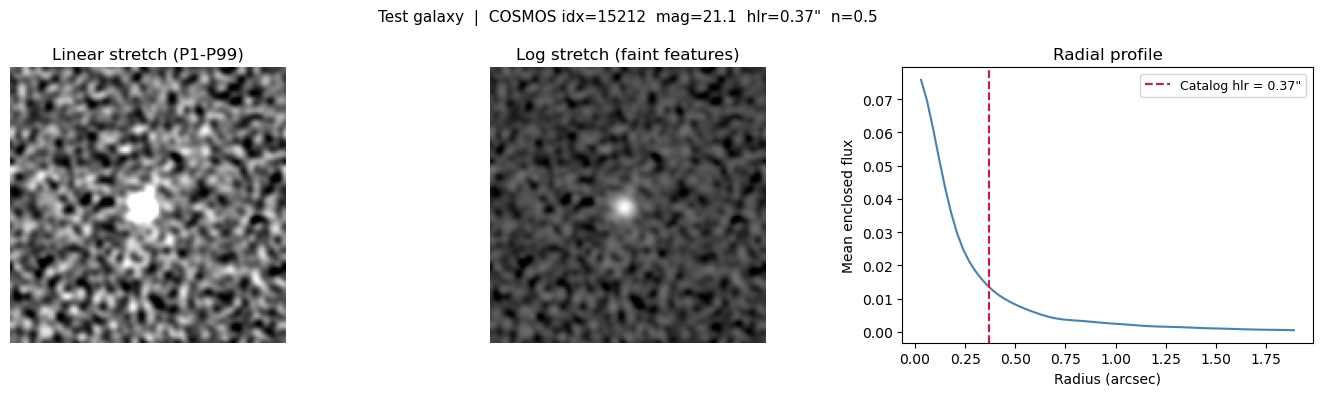

In [11]:
test_cat_idx = int(sampled['index'].iloc[0])
test_row     = sampled.iloc[0]

print(f'Test galaxy:')
print(f'  Catalog index : {test_cat_idx}')
print(f'  mag_auto      : {test_row["mag_auto"]:.2f}')
print(f'  hlr           : {test_row["hlr_arcsec"]:.3f}"')
print(f'  Sersic n      : {test_row["sersic_n"]:.2f}')
print(f'  Elongation    : {test_row["elongation"]:.2f}\n')

test_img = draw_galaxy_image(test_cat_idx, cosmos_cat)

if test_img is not None:
    print('[OK] Draw succeeded.')
    print(f'  Output shape : {test_img.shape}')
    print(f'  Value range  : [{test_img.min():.4g}, {test_img.max():.4g}]')
    print(f'  NaN count    : {np.isnan(test_img).sum()}')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        f'Test galaxy  |  COSMOS idx={test_cat_idx}  '
        f'mag={test_row["mag_auto"]:.1f}  '
        f'hlr={test_row["hlr_arcsec"]:.2f}"  '
        f'n={test_row["sersic_n"]:.1f}',
        fontsize=11
    )

    # Linear stretch
    p1, p99 = np.percentile(test_img, [1, 99])
    axes[0].imshow(test_img, cmap='gray', origin='lower', vmin=p1, vmax=p99)
    axes[0].set_title('Linear stretch (P1-P99)')
    axes[0].axis('off')

    # Log stretch — reveals faint outer structure
    img_pos = np.clip(test_img - p1, 0, None)
    axes[1].imshow(np.log1p(img_pos * 100), cmap='gray', origin='lower')
    axes[1].set_title('Log stretch (faint features)')
    axes[1].axis('off')

    # Radial profile
    cy, cx = np.array(test_img.shape) // 2
    max_r  = min(cy, cx)
    radii  = np.arange(1, max_r)
    profile = [
        np.mean(test_img[cy - r : cy + r + 1, cx - r : cx + r + 1])
        for r in radii
    ]
    axes[2].plot(radii * PIXEL_SCALE_ARCSEC, profile, color='steelblue', linewidth=1.5)
    axes[2].axvline(
        test_row['hlr_arcsec'], color='crimson', linestyle='--',
        label=f'Catalog hlr = {test_row["hlr_arcsec"]:.2f}"'
    )
    axes[2].set_xlabel('Radius (arcsec)')
    axes[2].set_ylabel('Mean enclosed flux')
    axes[2].set_title('Radial profile')
    axes[2].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'test_galaxy.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('[FAILED] Test draw returned None.')
    print('Check: did Cell 2 (catalog download) complete successfully?')

## Cell 11 — Bulk extraction loop (50 galaxies)

In [12]:
raw_images = []    # raw float32 arrays before normalisation
meta_list  = []    # metadata dicts
failed_idx = []    # catalog indices that failed

print(f'Drawing {len(sampled)} galaxies ...')
print('(Typical time: 1-5 minutes for 50 galaxies on a modern CPU)\n')

for i, row in tqdm(sampled.iterrows(), total=len(sampled), desc='Drawing galaxies'):
    cat_idx = int(row['index'])
    img     = draw_galaxy_image(cat_idx, cosmos_cat)

    if img is None:
        failed_idx.append(cat_idx)
        continue

    # Reject constant or empty images
    if img.max() - img.min() < 1e-9:
        failed_idx.append(cat_idx)
        continue

    draw_id = len(raw_images)
    raw_images.append(img)
    meta_list.append({
        'draw_id'    : draw_id,
        'cat_index'  : cat_idx,
        'mag_auto'   : float(row['mag_auto']),
        'hlr_arcsec' : float(row['hlr_arcsec']),
        'sersic_n'   : float(row['sersic_n']),
        'q_axis'     : float(row['q_axis']),
        'elongation' : float(row['elongation']),
        'pixel_scale': PIXEL_SCALE_ARCSEC,
        'n_pix'      : N_PIX,
    })

print(f'\nSuccessfully drawn : {len(raw_images)} / {len(sampled)}')
if failed_idx:
    print(f'Failed (skipped)   : {len(failed_idx)}  indices: {failed_idx}')

Drawing 50 galaxies ...
(Typical time: 1-5 minutes for 50 galaxies on a modern CPU)



Drawing galaxies: 100%|█████████████████████████████████████████████████████████████████| 50/50 [00:18<00:00,  2.78it/s]


Successfully drawn : 43 / 50
Failed (skipped)   : 7  indices: [53671, 53121, 54887, 54557, 52292, 51215, 51180]


## Cell 12 — Normalisation pipeline

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Replace NaN/Inf with 0 | GalSim sometimes produces NaN at image edges |
| 2 | Sky subtraction (3-sigma clipped border median) | Remove DC offset from sky background |
| 3 | Clip negative values to 0 | Sky-subtraction artefacts |
| 4 | Divide by 99th-percentile flux | Maps galaxy flux robustly to [0, 1] |

After this, each saved `.npy` is a float32 array in [0, 1] at 0.05"/px.

In [13]:
def normalise_cutout(img):
    """
    Normalise a raw GalSim galaxy image for use as a lenstronomy source.

    Returns
    -------
    img_norm : float32 array with values in [0, 1]
    norm_meta: dict with sky_level and p99_flux for later reference
    """
    img = img.copy().astype(np.float32)

    # Step 1: Clean non-finite values
    img = np.where(np.isfinite(img), img, 0.0)

    # Step 2: Sky subtraction using 3-sigma clipped median of the border annulus.
    # We use the outermost 12% of pixels as the sky estimate.
    h, w   = img.shape
    margin = max(2, int(0.12 * min(h, w)))
    border = np.concatenate([
        img[:margin, :].ravel(),
        img[-margin:, :].ravel(),
        img[margin:-margin, :margin].ravel(),
        img[margin:-margin, -margin:].ravel(),
    ])
    finite_border = border[np.isfinite(border)]
    if len(finite_border) > 0:
        clipped, _, _ = sigmaclip(finite_border, low=3.0, high=3.0)
        sky_level = float(np.median(clipped)) if len(clipped) > 0 else 0.0
    else:
        sky_level = 0.0
    img -= sky_level

    # Step 3: Clip negatives (sky-subtraction artefacts)
    img = np.clip(img, 0.0, None)

    # Step 4: Normalise by 99th percentile
    p99 = float(np.percentile(img, 99))
    if p99 > 0:
        img = img / p99
        img = np.clip(img, 0.0, 1.0)

    return img, {'sky_level': sky_level, 'p99_flux': p99}


cutouts_norm = []
for img, meta in zip(raw_images, meta_list):
    img_norm, norm_meta = normalise_cutout(img)
    meta.update(norm_meta)
    cutouts_norm.append(img_norm)

print(f'Normalised {len(cutouts_norm)} images.')

all_px = np.concatenate([c.ravel() for c in cutouts_norm])
print(f'\nPost-normalisation pixel statistics (all {len(cutouts_norm)} images combined):')
print(f'  Min    : {all_px.min():.6f}')
print(f'  Max    : {all_px.max():.6f}')
print(f'  Mean   : {all_px.mean():.6f}')
print(f'  Std    : {all_px.std():.6f}')
print(f'  Median : {np.median(all_px):.6f}')

Normalised 43 images.

Post-normalisation pixel statistics (all 43 images combined):
  Min    : 0.000000
  Max    : 1.000000
  Mean   : 0.109551
  Std    : 0.185889
  Median : 0.022928


## Cell 13 — Save normalised cutouts

In [14]:
npy_dir = OUT_DIR / 'npy'

for meta, img in zip(meta_list, cutouts_norm):
    fname = f'galaxy_{meta["draw_id"]:04d}.npy'
    np.save(npy_dir / fname, img.astype(np.float32))

# Save metadata JSON for cross-referencing in the lensing simulation notebook
meta_path = OUT_DIR / 'cutout_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(meta_list, f, indent=2)

print(f'Saved {len(cutouts_norm)} .npy files to: {npy_dir.resolve()}')
print(f'Metadata JSON saved to        : {meta_path.resolve()}')
print(f'Example: galaxy_0000.npy  ->  shape {cutouts_norm[0].shape},  dtype float32')

Saved 43 .npy files to: /mnt/c/Users/upraj/Prajwal/GSOC/DeepLense/DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday/cosmos_cutouts/npy
Metadata JSON saved to        : /mnt/c/Users/upraj/Prajwal/GSOC/DeepLense/DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday/cosmos_cutouts/cutout_metadata.json
Example: galaxy_0000.npy  ->  shape (128, 128),  dtype float32


## Cell 14 — 5x10 visualisation grid of all 50 cutouts

Visually inspect every cutout:
- OK: centred galaxy with visible morphology and sky background
- FLAG: bright star contaminating the frame
- FLAG: all-zeros or uniform image (failed draw)
- FLAG: strong ringing / grid artefacts (reconvolution issue)

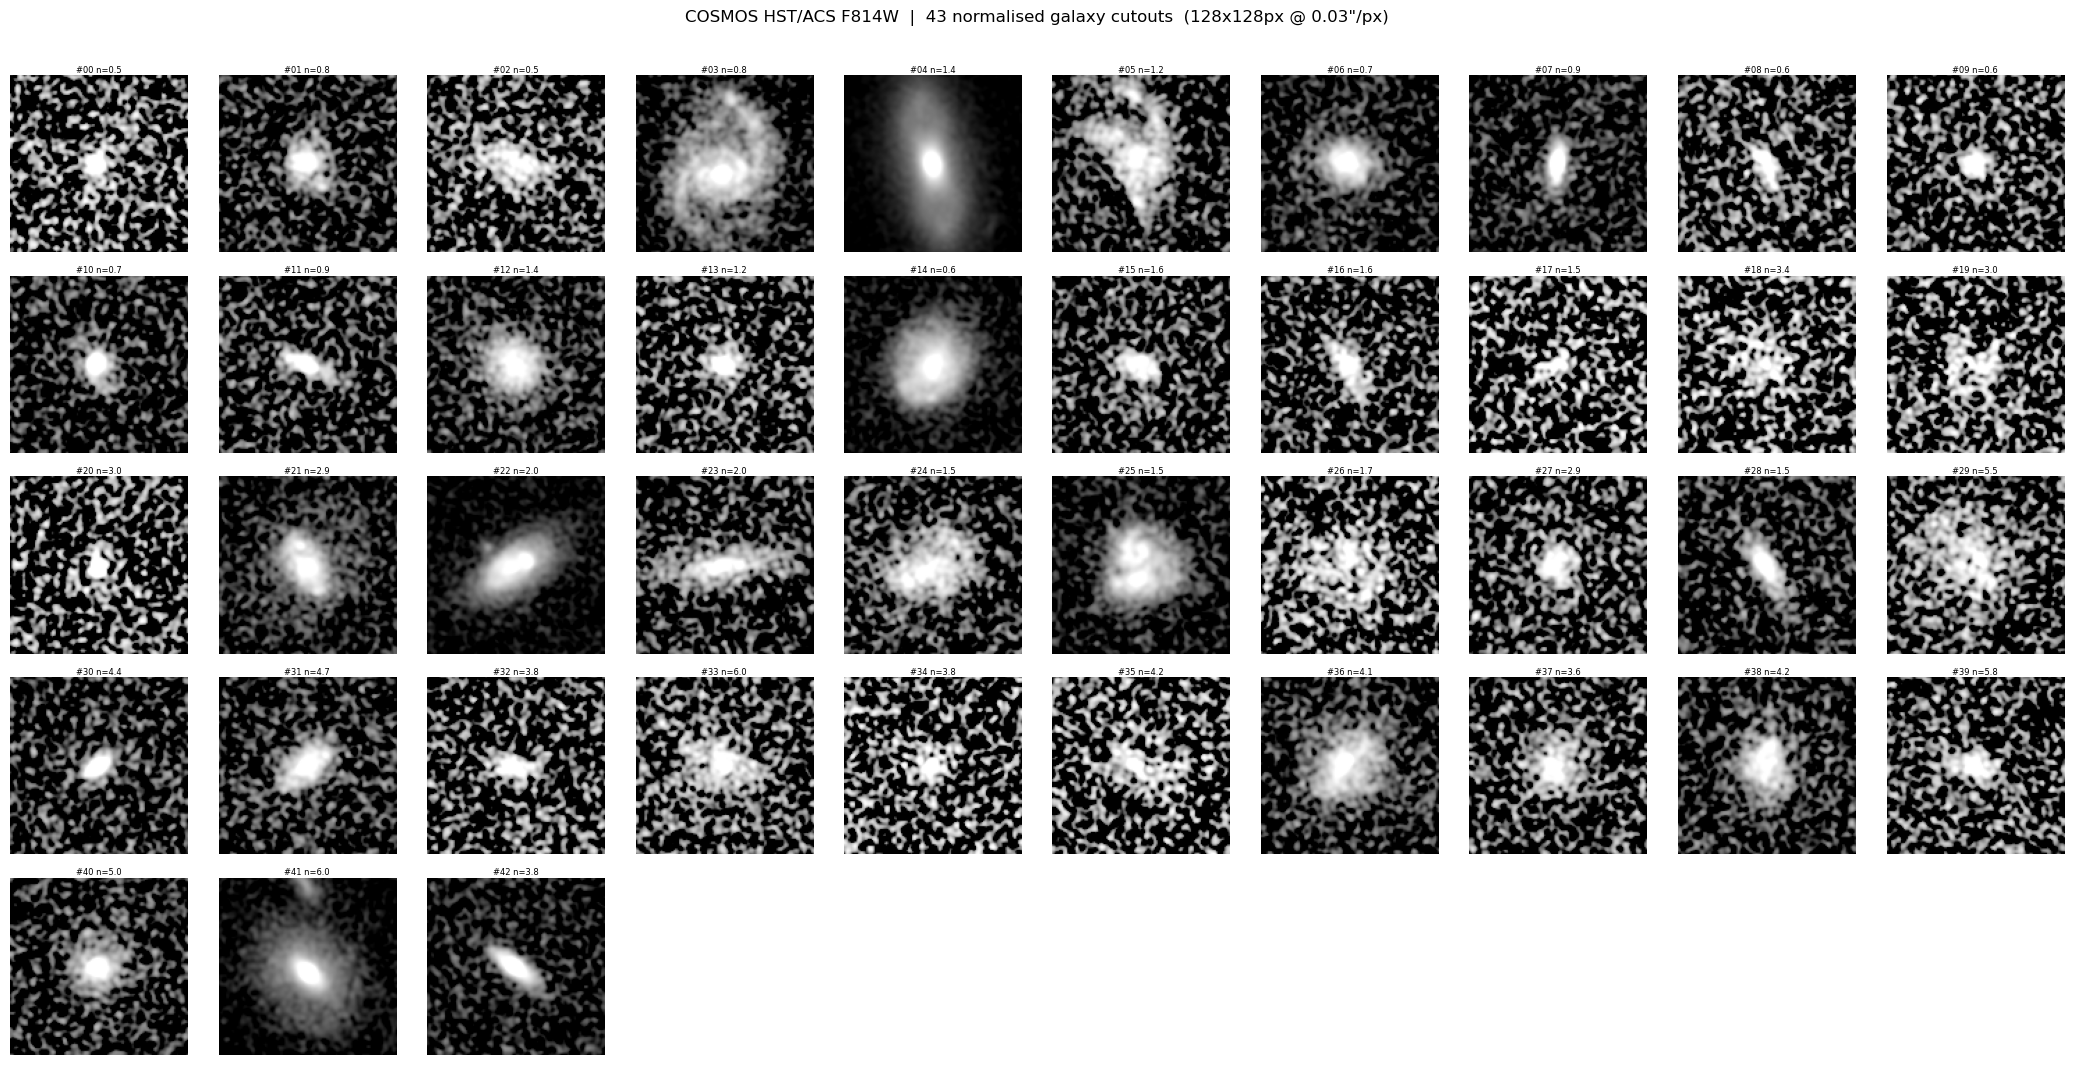

Saved: galaxy_grid.png


In [15]:
n_show = len(cutouts_norm)
n_cols = 10
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.1, n_rows * 2.1))
axes      = axes.flatten()

for i, (img, meta) in enumerate(zip(cutouts_norm, meta_list)):
    ax = axes[i]
    img_disp = np.log1p(img * 30)  # log stretch for best visibility
    ax.imshow(
        img_disp, cmap='gray', origin='lower',
        vmin=np.percentile(img_disp, 2),
        vmax=np.percentile(img_disp, 99),
    )
    ax.set_title(f'#{i:02d} n={meta["sersic_n"]:.1f}', fontsize=6, pad=2)
    ax.axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(
    f'COSMOS HST/ACS F814W  |  {n_show} normalised galaxy cutouts  '
    f'({N_PIX}x{N_PIX}px @ {PIXEL_SCALE_ARCSEC}"/px)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'galaxy_grid.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved: galaxy_grid.png')

## Cell 15 — Diversity diagnostics

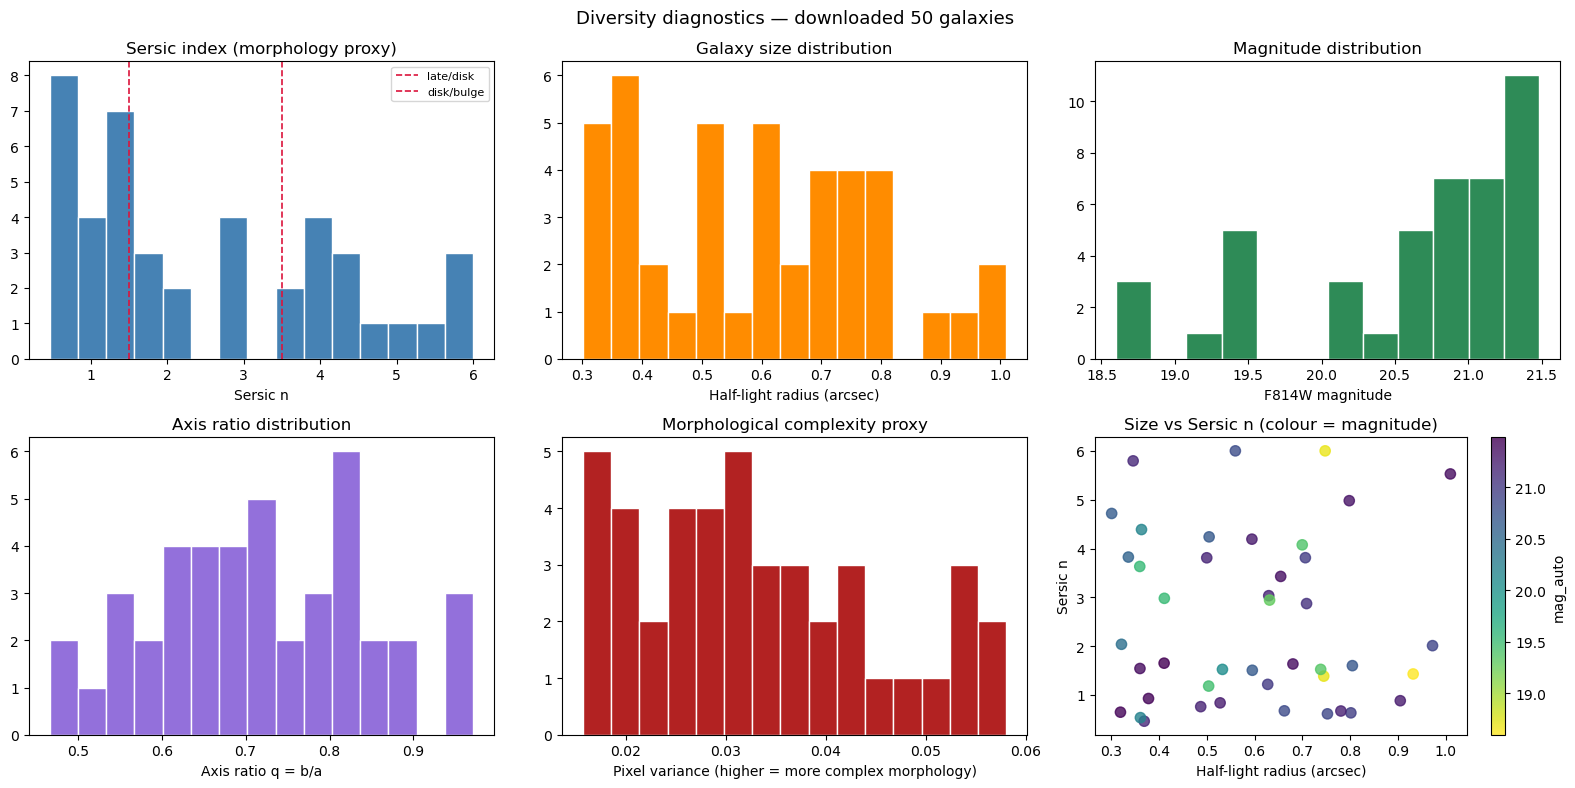

Saved: diversity_diagnostics.png


In [16]:
meta_df = pd.DataFrame(meta_list)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle('Diversity diagnostics — downloaded 50 galaxies', fontsize=13)

# 1. Sersic n
axes[0].hist(meta_df['sersic_n'], bins=15, color='steelblue', edgecolor='white')
for b, lab in [(1.5, 'late/disk'), (3.5, 'disk/bulge')]:
    axes[0].axvline(b, color='crimson', linestyle='--', linewidth=1.2, label=lab)
axes[0].set_xlabel('Sersic n')
axes[0].set_title('Sersic index (morphology proxy)')
axes[0].legend(fontsize=8)

# 2. Half-light radius
axes[1].hist(meta_df['hlr_arcsec'], bins=15, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Half-light radius (arcsec)')
axes[1].set_title('Galaxy size distribution')

# 3. Magnitude
axes[2].hist(meta_df['mag_auto'], bins=12, color='seagreen', edgecolor='white')
axes[2].set_xlabel('F814W magnitude')
axes[2].set_title('Magnitude distribution')

# 4. Axis ratio
axes[3].hist(meta_df['q_axis'], bins=15, color='mediumpurple', edgecolor='white')
axes[3].set_xlabel('Axis ratio q = b/a')
axes[3].set_title('Axis ratio distribution')

# 5. Pixel variance as complexity proxy
pixel_vars = [float(np.var(c)) for c in cutouts_norm]
axes[4].hist(pixel_vars, bins=15, color='firebrick', edgecolor='white')
axes[4].set_xlabel('Pixel variance (higher = more complex morphology)')
axes[4].set_title('Morphological complexity proxy')

# 6. Scatter: hlr vs sersic_n, coloured by magnitude
sc = axes[5].scatter(
    meta_df['hlr_arcsec'], meta_df['sersic_n'],
    c=meta_df['mag_auto'], cmap='viridis_r', alpha=0.8, s=55
)
plt.colorbar(sc, ax=axes[5], label='mag_auto')
axes[5].set_xlabel('Half-light radius (arcsec)')
axes[5].set_ylabel('Sersic n')
axes[5].set_title('Size vs Sersic n (colour = magnitude)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'diversity_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: diversity_diagnostics.png')

## Cell 16 — Centroid offset check

Verify each galaxy's flux is centred in the cutout.
lenstronomy assumes the source galaxy is at the source position —
a strongly off-centre cutout would introduce a positional offset in every simulated lens.

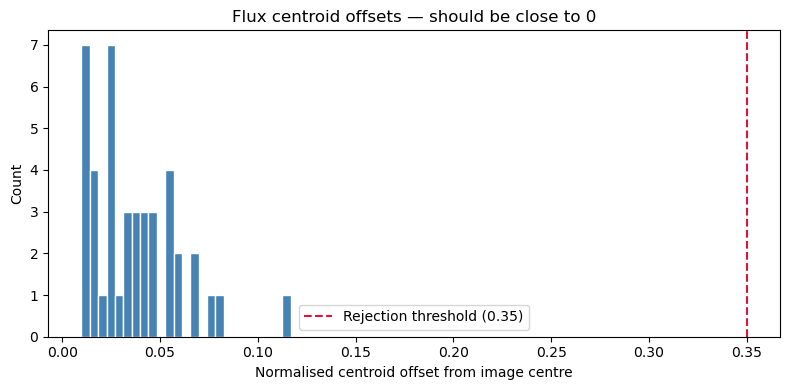

Flagged as off-centre (> 0.35): []
[OK] All galaxies well-centred.


In [17]:
threshold    = 0.35   # fraction of image half-width
offsets      = []
flagged_ids  = []

for i, img in enumerate(cutouts_norm):
    h, w  = img.shape
    cy, cx = h // 2, w // 2

    total = img.sum()
    if total < 1e-9:
        offsets.append(np.nan)
        continue

    ys, xs = np.mgrid[0:h, 0:w]
    y_c    = (ys * img).sum() / total
    x_c    = (xs * img).sum() / total

    dy  = (y_c - cy) / cy
    dx  = (x_c - cx) / cx
    off = np.sqrt(dx**2 + dy**2)
    offsets.append(off)

    if off > threshold:
        flagged_ids.append(i)

offsets = np.array(offsets)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(offsets[np.isfinite(offsets)], bins=25, color='steelblue', edgecolor='white')
ax.axvline(threshold, color='crimson', linestyle='--', label=f'Rejection threshold ({threshold})')
ax.set_xlabel('Normalised centroid offset from image centre')
ax.set_ylabel('Count')
ax.set_title('Flux centroid offsets — should be close to 0')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'centroid_check.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Flagged as off-centre (> {threshold}): {flagged_ids}')
if not flagged_ids:
    print('[OK] All galaxies well-centred.')

## Cell 17 — Final summary and checklist

In [18]:
print('=' * 62)
print('STAGE 0 COSMOS CUTOUT EXTRACTION -- COMPLETE')
print('=' * 62)
print(f'  Galaxies extracted      : {len(cutouts_norm)}')
print(f'  Image size              : {N_PIX} x {N_PIX} px')
print(f'  Pixel scale             : {PIXEL_SCALE_ARCSEC}"/px  (native COSMOS ACS)')
print(f'  Field of view per image : {N_PIX * PIXEL_SCALE_ARCSEC}" x {N_PIX * PIXEL_SCALE_ARCSEC}"')
print(f'  Galaxy type used        : RealGalaxy (actual HST pixel data)')
print(f'  Normalisation           : sky-subtracted, scaled to [0, 1]')
print()
print('Output files:')
print(f'  cosmos_cutouts/npy/galaxy_XXXX.npy    ({len(cutouts_norm)} files)')
print(f'  cosmos_cutouts/cutout_metadata.json')
print(f'  cosmos_cutouts/galaxy_grid.png')
print(f'  cosmos_cutouts/diversity_diagnostics.png')
print()
print('NEXT NOTEBOOK: 02_lensing_simulation_prototype.ipynb')
print('  -> Load galaxy_XXXX.npy as lenstronomy InterpolatedLightModel')
print('  -> Apply SIE lens + Moffat PSF + HSC-level noise')
print('  -> Produce first (LR 64x64, HR 128x128) lensed image pairs')
print()
print('OPEN QUESTIONS FOR MENTORS BEFORE NOTEBOOK 02:')
print('  1. Keep pixel scale at 0.05"/px or resample to HSC 0.168"/px?')
print('  2. Target SNR range for arc flux normalisation in lenstronomy?')
print('  3. Switch to 25.2 sample for full 60K dataset?')
print('=' * 62)

STAGE 0 COSMOS CUTOUT EXTRACTION -- COMPLETE
  Galaxies extracted      : 43
  Image size              : 128 x 128 px
  Pixel scale             : 0.03"/px  (native COSMOS ACS)
  Field of view per image : 3.84" x 3.84"
  Galaxy type used        : RealGalaxy (actual HST pixel data)
  Normalisation           : sky-subtracted, scaled to [0, 1]

Output files:
  cosmos_cutouts/npy/galaxy_XXXX.npy    (43 files)
  cosmos_cutouts/cutout_metadata.json
  cosmos_cutouts/galaxy_grid.png
  cosmos_cutouts/diversity_diagnostics.png

NEXT NOTEBOOK: 02_lensing_simulation_prototype.ipynb
  -> Load galaxy_XXXX.npy as lenstronomy InterpolatedLightModel
  -> Apply SIE lens + Moffat PSF + HSC-level noise
  -> Produce first (LR 64x64, HR 128x128) lensed image pairs

OPEN QUESTIONS FOR MENTORS BEFORE NOTEBOOK 02:
  1. Keep pixel scale at 0.05"/px or resample to HSC 0.168"/px?
  2. Target SNR range for arc flux normalisation in lenstronomy?
  3. Switch to 25.2 sample for full 60K dataset?
